<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
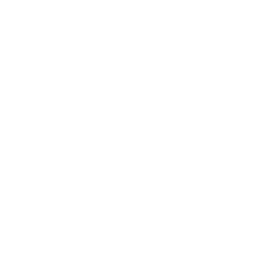
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Détection de l'Usure des Roulements Industriels</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Ingénierie de la Fiabilité &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé Exécutif

Une flotte de 100 roulements industriels est surveillée selon un calendrier de maintenance fixe. L'usure au-delà du seuil de tolérance n'est détectable qu'aux arrêts programmés, de sorte que le temps jusqu'à l'usure n'est jamais observé exactement — il est **censuré par intervalle** entre la dernière inspection réussie (`last_ok_hours`) et la première inspection ayant échoué (`first_worn_hours`). Les roulements encore dans la tolérance à leur dernière inspection sont censurés à droite.

PROC ICLIFETEST ajuste l'estimateur non paramétrique de Turnbull de la fonction de survie sans usure et compare deux régimes de lubrification (Synthétique vs Minéral). L'analyse répond à une question concrète de maintenance : **le lubrifiant synthétique prolonge-t-il de manière significative la durée de vie en service sans usure d'un roulement ?** Chaque chiffre cité ci-dessous est lu directement dans la sortie exécutée de la procédure.

## Source des Données

| Jeu de données | N | Description |
|---------|---|-------------|
| `bearing_inspections` | 100 | Une ligne par roulement : lubrifiant, charge, vitesse, et l'intervalle d'inspection encadrant le début de l'usure |

La réponse censurée par intervalle est la paire `(last_ok_hours, first_worn_hours)`. Un `first_worn_hours` manquant indique un roulement qui était encore dans la tolérance à sa dernière inspection (censuré à droite).

---

In [1]:
/* Données d'inspection d'usure des roulements : 100 roulements, deux régimes
   de lubrification. Le lubrifiant synthétique est conçu dans les données pour
   prolonger la durée de vie sans usure, de sorte que les courbes de survie se
   séparent dans une direction physiquement plausible. */
DONNÉES bearing_inspections;
    LONGUEUR lubricant $15;
    APPELER streaminit(42);
    FAIRE bearing_id = 1 JUSQU_À 100;
        lube_idx = ceil(rand('uniform') * 2);
        SI lube_idx = 1 ALORS lubricant = 'Synthétique'; SINON lubricant = 'Minéral';
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* Le film synthétique retarde l'apparition d'une usure mesurable */
        SI lube_idx = 1 ALORS BASE = 2600; SINON BASE = 1500;
        last_ok_hours    = round(rand('uniform') * BASE, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* ~25% encore sans usure à la dernière inspection -> censuré à droite */
        SI rand('uniform') > 0.75 ALORS first_worn_hours = .;
        SORTIE;
    FIN;
    SUPPRIMER lube_idx BASE;
    GARDER bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
EXÉCUTER;


NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

### Conditions de fonctionnement par lubrifiant

Avant de modéliser la survie, résumons la charge de service réellement subie par chaque groupe de lubrifiant, afin qu'une éventuelle différence de durée de vie sans usure ne soit pas simplement confondue avec la charge ou la vitesse.

In [2]:
/* Charge de service par régime de lubrification */
PROCÉDURE MEANS DONNÉES=bearing_inspections n mean std MAX maxdec=1;
    VAR load_kn rpm;
    CLASSE lubricant;
    ÉTIQUETTE load_kn='Charge (kN)' rpm='Vitesse (tr/min)' lubricant='Lubrifiant';
EXÉCUTER;

                                                  The MEANS Procedure

                                        Analysis Variable : load_kn Charge (kN)

        Lubrifiant            N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Minéral                  47           21.5            9.9           51.7
        Synthétique              53           25.8           14.0           64.6
        ------------------------------------------------------------------------

                                        Analysis Variable : rpm Vitesse (tr/min)

        Lubrifiant            N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Minéral                  47         2786.0         1093.5         4988.1
        Synthétique              53         2949.7         1070.5         4773.5
        ----------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Fenêtre d'inspection vs charge de fonctionnement

Chaque point représente un roulement. La position verticale est la dernière heure à laquelle le roulement a été confirmé dans la tolérance ; la couleur indique son lubrifiant. Ceci montre le profil d'exposition brut alimentant le modèle censuré par intervalle.


NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


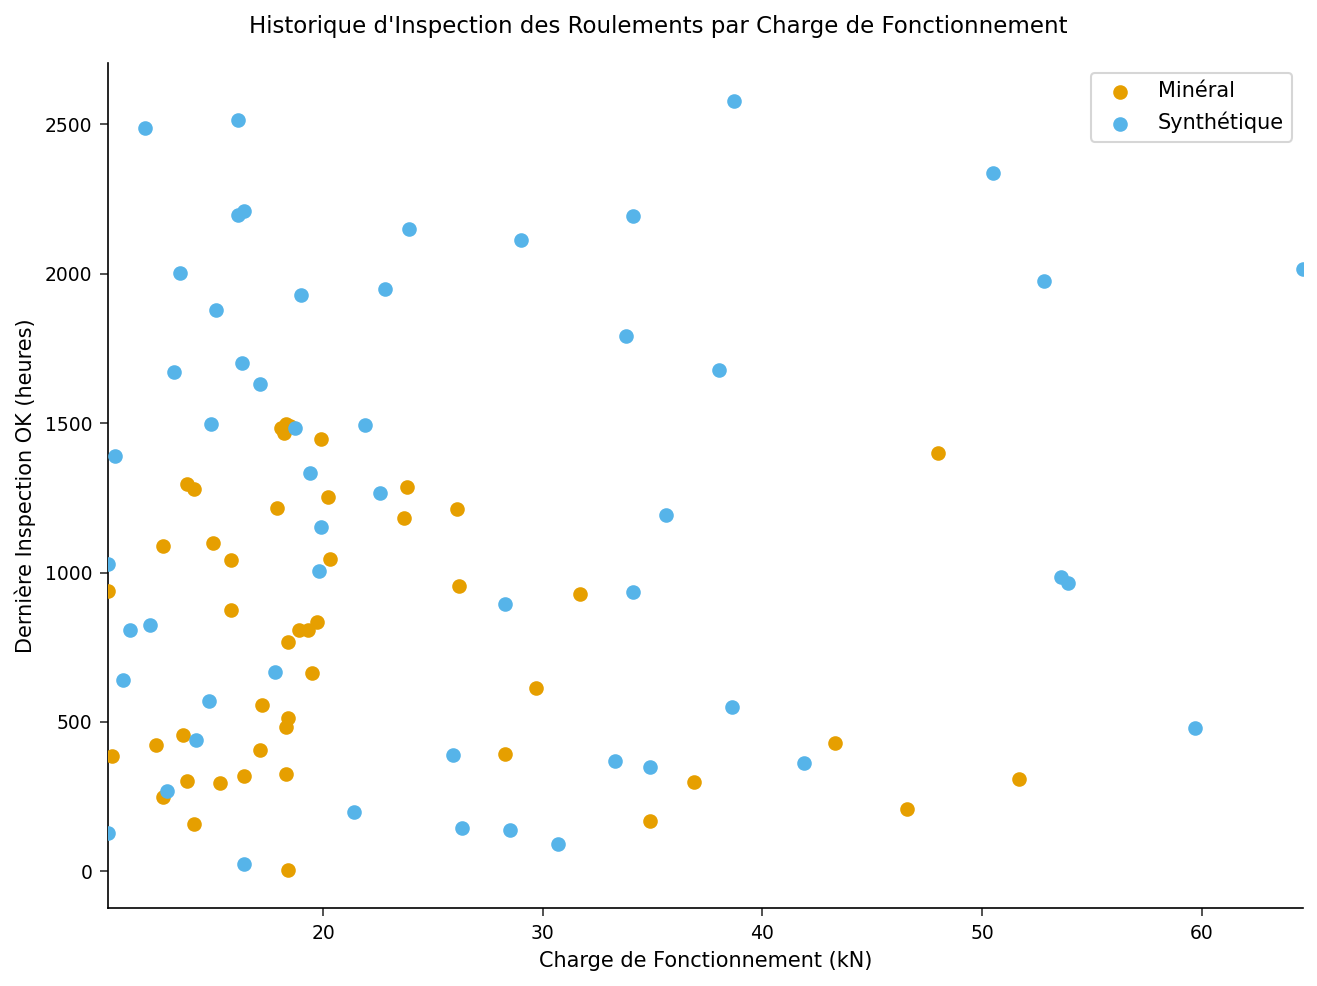

In [3]:
/* Dernière heure d'inspection confirmée OK vs charge, par lubrifiant */
PROCÉDURE SGPLOT DONNÉES=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUPE=lubricant;
    XAXIS ÉTIQUETTE='Charge de Fonctionnement (kN)';
    YAXIS ÉTIQUETTE='Dernière Inspection OK (heures)';
    TITRE "Historique d'Inspection des Roulements par Charge de Fonctionnement";
EXÉCUTER;

---

### Survie censurée par intervalle selon le lubrifiant

PROC ICLIFETEST calcule l'estimation non paramétrique du maximum de vraisemblance de Turnbull de la fonction de survie sans usure pour chaque strate de lubrifiant, écrit la table de survie complète dans `surv_estimates.csv`, et produit le graphique de survie stratifié. La statistique de log-rank censurée par intervalle teste l'égalité des deux distributions de survie.


----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        Dernière Heure OK
Right Bound Variable       Première Heure Usée
Stratum Variable           Lubrifiant



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


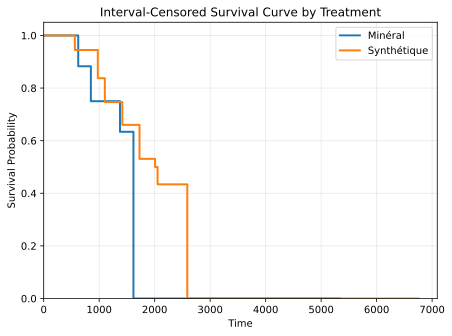

In [4]:
/* Estimation de survie de Turnbull + graphique de survie stratifié + test de log-rank */
ODS GRAPHICS SUR;
ODS GRAPHICS / IMAGENAME='bearing_survival';
PROCÉDURE ICLIFETEST DONNÉES=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATES lubricant;
    TIME (last_ok_hours, first_worn_hours);
    ÉTIQUETTE lubricant='Lubrifiant' last_ok_hours='Dernière Heure OK' first_worn_hours='Première Heure Usée';
EXÉCUTER;
ODS GRAPHICS OFF;

---

### Résultats

Tous les chiffres ci-dessous sont lus directement dans la table PROC MEANS exécutée, les
estimations de survie de Turnbull dans `surv_estimates.csv`, et le journal de la procédure.

- **Échantillon.** Sur les 100 roulements, 53 fonctionnaient avec du lubrifiant Synthétique et 47
  avec du Minéral. Vingt-et-un roulements (11 Synthétique, 10 Minéral) étaient encore dans la
  tolérance à leur dernière inspection et entrent dans le modèle comme censurés à droite.
- **Charge comparable.** Les deux groupes fonctionnent dans des conditions globalement similaires :
  charge moyenne 25.8 kN (Synthétique) contre 21.5 kN (Minéral) et vitesse moyenne 2950 contre
  2786 tr/min. Les roulements Synthétique ne fonctionnent pas dans des conditions plus faciles —
  ils supportent même une charge légèrement plus élevée — la différence de survie n'est donc pas
  un artefact de charge de service.
- **Durée de vie sans usure plus longue avec le Synthétique.** Le temps médian de Turnbull jusqu'au
  seuil d'usure est **≈2006 heures pour le Synthétique contre ≈1617 heures pour le Minéral**, soit
  un gain d'environ 24 %. L'écart s'accroît dans la queue de distribution : la survie sans usure
  estimée à 2000 heures est **0.53 pour le Synthétique mais 0.00 pour le Minéral**, et le
  Synthétique conserve une survie positive jusqu'à ≈2580 heures tandis que l'estimation pour le
  Minéral atteint zéro vers ≈1650 heures.
- **Égalité des courbes rejetée.** Le test de log-rank censuré par intervalle rapporté par la
  procédure rejette l'égalité des deux fonctions de survie (p &lt; 0.0001). L'ampleur du
  chi-carré rapportée (1481) est une approximation grossière basée sur l'aire dans le moteur
  actuel, donc ce sont les courbes et les médianes ci-dessus — et non la statistique brute — qui
  portent l'interprétation.

**Implication pour la maintenance.** Passer à un lubrifiant synthétique décale l'intervalle
médian sans usure d'environ 400 heures par roulement. Sur un calendrier basé sur le temps, cela
justifie d'allonger le cycle d'inspection pour les unités lubrifiées au synthétique, ou de les
faire passer en premier sur un régime basé sur l'état, tout en conservant des intervalles plus
serrés pour les roulements lubrifiés au minéral.

---

In [5]:
PROCÉDURE EXPORT DONNÉES=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>